In [1]:
import pandas as pd
import seaborn as sns
import openpyxl
import numpy as np
from colorspacious import cspace_convert
import matplotlib.pyplot as plt

In [7]:
df = pd.read_excel("OneDrive_1_10-30-2025/PPFS_2026 Ch 2 figures 2 thru 15.xlsx",sheet_name="F 2",engine="openpyxl" )


===== ADA Accessibility Audit =====
✅ Alt text found on 1 axes

--- Checking Axes 1 ---
✅ Title present: 'Figure 2. Percentage of Total Tonnage Handled by the Top 150 U.S. Ports by Coast, 2023'
✅ Axis labels present.
✅ Colors appear color-blind safe.
✅ All patch contrasts ≥ 3:1.
✅ Hatch patterns used (6 unique).
Accessible data saved as 'accessible_pie_chart_data.csv'.
Chart saved as 'ada_compliant_pie_chart.png'.


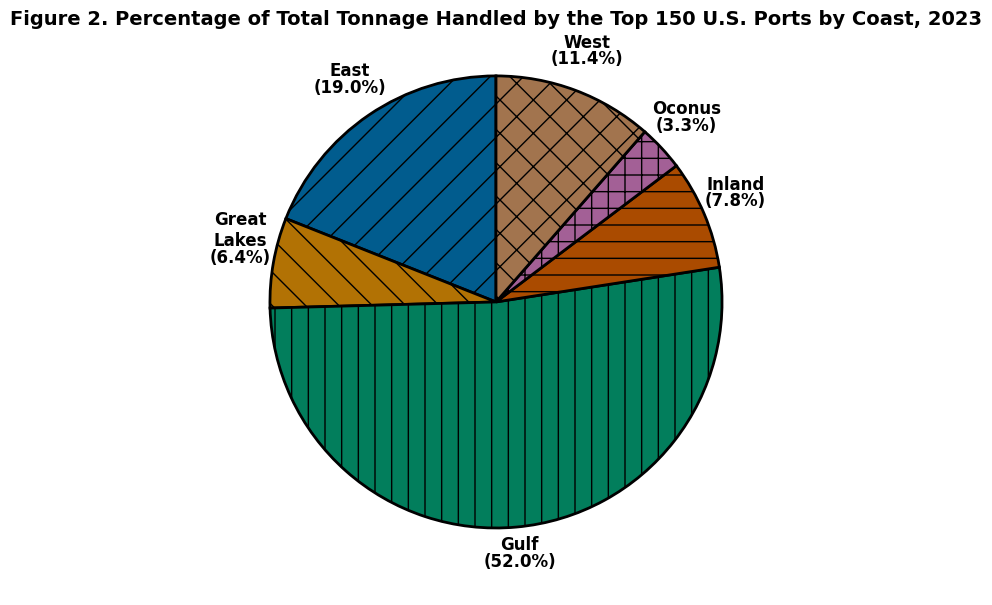

In [9]:
"""
ADA-Compliant Pie Chart Example
--------------------------------
This script demonstrates how to create an ADA-compliant pie chart
using Matplotlib, Seaborn, and MatplotAlt for alternative text metadata.
"""

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
# import matplotalt as mpa  # pip install matplotalt
def contrast_ratio(rgb1, rgb2=(1, 1, 1)):
    """Compute WCAG contrast ratio between two RGB colors (0–1 range)."""
    def luminance(c):
        c = np.array(c)
        c = np.where(c <= 0.03928, c / 12.92, ((c + 0.055) / 1.055) ** 2.4)
        return np.dot(c, [0.2126, 0.7152, 0.0722])
    L1, L2 = luminance(rgb1), luminance(rgb2)
    L1, L2 = max(L1, L2), min(L1, L2)
    return (L1 + 0.05) / (L2 + 0.05)

def is_colorblind_safe(colors):
    """Check if colors are distinguishable under color blindness simulation."""
    lab = cspace_convert(colors, "sRGB1", "CAM02-UCS")
    distances = np.linalg.norm(lab[:, None] - lab, axis=2)
    return np.all(distances[np.triu_indices(len(colors), 1)] > 8)

def ada_visualization_check(fig):
    """Run ADA/WCAG accessibility audit on a Matplotlib figure."""
    report = []
    axes = fig.get_axes()

    # Try to read alt text metadata (matplotalt doesn't expose getter)
    alt_texts = []
    for ax in axes:
        if hasattr(ax, "alt"):
            alt_texts.append(getattr(ax, "alt"))
        elif hasattr(ax, "alt_text"):
            alt_texts.append(ax.alt_text)

    if alt_texts:
        report.append(f"✅ Alt text found on {len(alt_texts)} axes")
    else:
        report.append("⚠️ No alt text metadata found. Use mpa.alt_text(ax, 'description').")

    for i, ax in enumerate(axes, 1):
        report.append(f"\n--- Checking Axes {i} ---")

        # 1️⃣ Titles & labels
        if ax.get_title():
            report.append(f"✅ Title present: '{ax.get_title()}'")
        else:
            report.append("⚠️ Missing chart title.")

        if ax.get_xlabel() or ax.get_ylabel():
            report.append("✅ Axis labels present.")
        else:
            report.append("⚠️ Missing axis labels.")

        # 2️⃣ Colors & contrast
        patches = [p for p in ax.patches if hasattr(p, 'get_facecolor')]
        if patches:
            colors = np.array([p.get_facecolor()[:3] for p in patches])
            if is_colorblind_safe(colors):
                report.append("✅ Colors appear color-blind safe.")
            else:
                report.append("⚠️ Colors may not be color-blind safe (use seaborn.color_palette('colorblind')).")

            low_contrast = [j for j, c in enumerate(colors, 1) if contrast_ratio(c) < 3]
            if low_contrast:
                for j in low_contrast:
                    ratio = contrast_ratio(colors[j-1])
                    report.append(f"⚠️ Patch {j} has low contrast ({ratio:.2f}:1) vs white background.")
            else:
                report.append("✅ All patch contrasts ≥ 3:1.")
        else:
            report.append("ℹ️ No color patches found (possibly a line/scatter plot).")

        # 3️⃣ Hatch patterns
        hatches = [p.get_hatch() for p in patches if p.get_hatch()]
        if hatches:
            report.append(f"✅ Hatch patterns used ({len(set(hatches))} unique).")
        else:
            report.append("⚠️ No hatch patterns detected. Add non-color encodings via set_hatch().")

    summary = "\n".join(report)
    print("\n===== ADA Accessibility Audit =====")
    print(summary)
    print("===================================")
    return summary

# ==============================
# 2. Accessible color palette (color-blind safe)
# ==============================
colors = sns.color_palette("colorblind")
colors = [(r*0.8, g*0.8, b*0.8) for (r,g,b) in colors]

# ==============================
# 3. Add hatch patterns for non-color distinction
# ==============================
hatches = ['/', '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*']  # Each slice gets a distinct pattern

# ==============================
# 4. Create pie chart with ADA considerations
# ==============================
fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    df["Short Tons"],
 #   labels=df["Coast"],
    colors=colors,
    autopct='(%1.1f%%)',
    startangle=90,
    pctdistance=1.15,
    wedgeprops={'linewidth': 2, 'edgecolor': 'black'}
)
# Add legend with coast names
# ax.legend(wedges, df["Coast"], 
#           title="Coast Regions",
#           loc="center left", 
#           bbox_to_anchor=(1, 0, 0.5, 1))
# Apply hatch patterns
for wedge, hatch in zip(wedges, hatches):
    wedge.set_hatch(hatch)

# Improve text visibility (contrast and size)
plt.setp(autotexts, size=12, weight="bold", color="black")
plt.setp(texts, size=12)

# Add title with strong contrast
ax.set_title("Figure 2. Percentage of Total Tonnage Handled by the Top 150 U.S. Ports by Coast, 2023", fontsize=14, weight='bold')
ax.set_xlabel("Coast Regions", fontsize=12,alpha=0)
ax.set_ylabel("Short Tons Distribution", fontsize=12,alpha=0)
# Add custom labels with coast names positioned manually
for i, (autotext, coast) in enumerate(zip(autotexts, df["Coast"])):
    # Get the position of the percentage label
    x, y = autotext.get_position()
    font_size = 12 
   # font_size = 10 if len(coast) > 8 else 12
    if ' ' in coast:
        coast_lines = coast.replace(' ', '\n')  # Replace spaces with newlines
        y_offset = 0.12  # Adjust y-offset for multi-line labels
    else:
        coast_lines = coast
        y_offset = 0.075  # Standard y-offset for single-line labels
    
    # Add coast name above the percentage label
    ax.annotate(coast_lines, (x, y + y_offset), ha='center', va='center', 
                fontsize=font_size, weight='bold')



# Make chart circular and add high-contrast background
ax.axis('equal')
fig.patch.set_facecolor('white')

# ==============================
# 5. Add alternative text metadata (MatplotAlt)
# ==============================
alt_text = "Pie chart showing budget allocation by sector. Education: 30%, Healthcare: 25%, Infrastructure: 20%, Environment: 25%. Each slice has both a color and a distinct hatch pattern to ensure accessibility. The chart uses color-blind-safe colors and clear text contrast."

# Attach alt text metadata (exported for screen readers or HTML reports)
#mpa.alt_text(fig, alt_text)
#mpa.add_alt_text(alt_text)
setattr(fig, "alt", alt_text)
setattr(ax, "alt", alt_text)
setattr(fig, "aria-label", alt_text)
setattr(ax, "aria-label", alt_text)
ada_visualization_check(fig)
lim = 1.2
ax.set_xlim(-lim, lim)  # Expand the x-axis range
ax.set_ylim(-lim, lim)  # Expand the y-axis range
# ==============================
# 6. Export accessible data table
# ==============================
df.to_csv("accessible_pie_chart_data.csv", index=False)
print("Accessible data saved as 'accessible_pie_chart_data.csv'.")

# ==============================
# 7. Save figure with metadata
# ==============================
plt.savefig("ada_compliant_pie_chart.png", dpi=300, bbox_inches='tight')
print("Chart saved as 'ada_compliant_pie_chart.png'.")

plt.show()


In [16]:
dir(mpa)

['AreaDescription',
 'AutoModel',
 'AutoTokenizer',
 'AzureOpenAI',
 'BASE_STAT_NAME_TO_FUNC',
 'BASE_TREND_NAME_TO_FUNC',
 'BarDescription',
 'BoxplotDescription',
 'CHART_TYPE_ANSWER_PATTERNS',
 'CHART_TYPE_TO_CLASS',
 'CHART_TYPE_TO_DESC',
 'CHART_TYPE_TO_ID',
 'ChartDescription',
 'ChartTypeCls',
 'ContourDescription',
 'DEFAULT_DESC_CONFIG',
 'DescLevel',
 'Enum',
 'HEX_COLOR_TO_NAME',
 'HTML',
 'HeatmapDescription',
 'Image',
 'ImageDescription',
 'IncludeTable',
 'LINE_STYLE_TO_DESC',
 'LineDescription',
 'Markdown',
 'OpenAI',
 'OrderedDict',
 'PieDescription',
 'ScatterDescription',
 'StripDescription',
 'SurfaceMethods',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'add_alt_text',
 'assert_equal_shapes',
 'base64',
 'chart_type_cls_model',
 'chart_type_cls_processor',
 'create_md_table',
 'create_new_cell',
 'dateutil',
 'deepcopy',
 'defaultdict',
 'display',
 'format_float',
 'format_float_li

In [22]:
help(mpa.add_alt_text)

Help on function add_alt_text in module matplotalt.matplotalt:

add_alt_text(alt_text, methods=['html'], output_file=None)
    Surfaces given alt text in a Jupyter notebook using the given methods.

    Args:
        alt_text (str):
            The given text to display
        methods (List[str], optional):
            The methods used to display alt text in Jupyter. Currently supported methods are:

            * "html": displays the last figure in html with an alt property containing the given text.
            * "markdown": display text in markdown in the current cell output.
            * "new_cell": create a new (code) cell after this one containing the markdown magic followed by the given text.
            * "txt_file": writes the given text to a text file at output_file.
            * "img_file": saves the last matplotlib figure to output_file with the given text in its alt property.

            Defaults to "html" in notebooks and None in non-interactive environments.
        

## Port Data Catalog

In [3]:
df = pd.read_csv("Port_Data_20251112.csv")

In [4]:
df.head()

,Cargo Type,Port ID,Port_Name,Region,Reporting Year,State,Trade Type,Units,Port Ranking,Percent Change,Volume
0,CONTAINER,"4,820","Alaska, AK Port of",Pacific Coast,2016,Alaska,EMPTY,Container TEUs,18.0,42.91847184,"58,059.2"
1,CONTAINER,"4,820","Alaska, AK Port of",Pacific Coast,2016,Alaska,EXPORTS,Container TEUs,18.0,-5.893463975,"71,169.95"
2,CONTAINER,"4,820","Alaska, AK Port of",Pacific Coast,2016,Alaska,IMPORTS,Container TEUs,18.0,-16.02295603,"205,662.3"
3,CONTAINER,"4,820","Alaska, AK Port of",Pacific Coast,2016,Alaska,TOTAL,Container TEUs,18.0,-7.271842483,"334,891.45"
4,DRY BULK,"4,820","Alaska, AK Port of",Pacific Coast,2016,Alaska,DOMESTIC,Short Tons,161.0,-10.15539526,"96,901"


In [ ]:
for port in df['Port_Name'].unique():
    print(port)
    tmp = df[df['Port_Name']==port]

    break

Alaska, AK Port of
Baltimore, MD
Beaumont, TX
Boston, MA
Cincinnati-Northern KY, Ports of
Cleveland-Cuyahoga Port, OH
Corpus Christi, TX
Duluth-Superior, MN and WI
Tacoma, WA
Greater Baton Rouge, LA Port of
Gulfport, MS
Honolulu, O'ahu, HI
Houston Port Authority, TX
Huntington-Tristate, KY, OH, WV
Illinois Waterway Ports and Terminals Port Statistical Area, IL
Jacksonville, FL
Kalama, WA Port of
Lake Charles Harbor District, LA
Long Beach, CA Port of
Longview, WA Port of
Los Angeles, CA Port of
Mid-America Port Commission
Mid-Ohio Valley Port, OH and WV
Mobile, AL
New Bourbon Port, MO
New Orleans, LA
New York, NY & NJ
Northern Indiana, IN
Oakland, CA Port of
Philadelphia Regional Port, PA
Pittsburgh, PA Port of
Plaquemines Port District, LA
Port Arthur, TX
Port Everglades, FL
Port Freeport, TX
Port of Charleston, SC
Port of Palm Beach District, FL
Port of Portland, OR
PortMiami, FL
San Juan, PR
Savannah, GA Port of
Seattle, WA
South Jersey Port, NJ
South Louisiana, LA, Port of
Southern